In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Basic shape and structure
print("Shape (rows, columns):", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n")
df.info()

Shape (rows, columns): (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    

In [3]:
# Missing values
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
# Duplicate records
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate customerIDs:", df['customerID'].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate customerIDs: 0


In [5]:
# Unique value counts for each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [6]:
# Separate numerical vs categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\hp\AppData\Local\Temp\ipykernel_12000\2943586548.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [7]:
# Statistical summary of numerical columns (check for outliers)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Check TotalCharges specifically — known quirk in this dataset
print(df['TotalCharges'].dtype)
print(df[df['TotalCharges'] == ' ']['TotalCharges'].count())  # blank-space entries

str
11


In [9]:
print(df['Churn'].value_counts())
print("\nPercentage:\n")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\hp\AppData\Local\Temp\ipykernel_12000\2878176833.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [ ]:
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print("NaNs created in TotalCharges:", df_clean['TotalCharges'].isnull().sum())

In [12]:
df_clean[df_clean['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [13]:
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

print("Remaining NaNs in TotalCharges:", df_clean['TotalCharges'].isnull().sum())
print("New shape:", df_clean.shape)

Remaining NaNs in TotalCharges: 0
New shape: (7043, 21)


In [14]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    print(f"{col}: {df_clean[col].unique()}")

OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


In [15]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

# Also check MultipleLines separately — it has a similar 'No phone service' pattern
print("MultipleLines unique values:", df_clean['MultipleLines'].unique())

MultipleLines unique values: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str


In [16]:
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# Final cleaning summary check
print("Shape:", df_clean.shape)
print("\nMissing values remaining:", df_clean.isnull().sum().sum())
print("\nTotalCharges dtype:", df_clean['TotalCharges'].dtype)
print("\nSample of cleaned service columns:")
df_clean[['OnlineSecurity', 'MultipleLines', 'TotalCharges', 'SeniorCitizen']].head()

Shape: (7043, 21)

Missing values remaining: 0

TotalCharges dtype: float64

Sample of cleaned service columns:


,OnlineSecurity,MultipleLines,TotalCharges,SeniorCitizen
0,No,No,29.85,0
1,Yes,No,1889.50,0
2,Yes,No,108.15,0
3,Yes,No,1840.75,0
4,No,No,151.65,0


In [17]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Confirm
print(df_clean['SeniorCitizen'].unique())
df_clean[['SeniorCitizen', 'OnlineSecurity', 'MultipleLines', 'TotalCharges']].head()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


,SeniorCitizen,OnlineSecurity,MultipleLines,TotalCharges
0,No,No,No,29.85
1,No,Yes,No,1889.50
2,No,Yes,No,108.15
3,No,Yes,No,1840.75
4,No,No,No,151.65


Matplotlib is building the font cache; this may take a moment.
C:\Users\hp\AppData\Local\Temp\ipykernel_12000\1342600229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Churn', palette=['#2ecc71', '#e74c3c'])


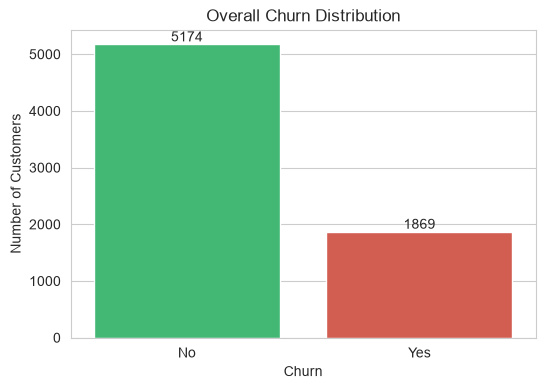

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_clean, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Overall Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

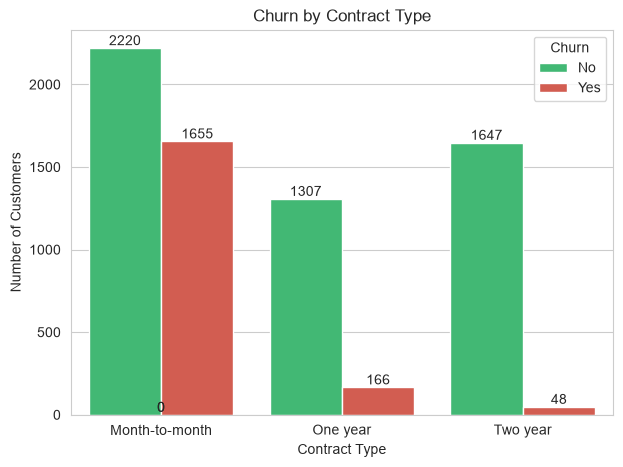

In [19]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df_clean, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

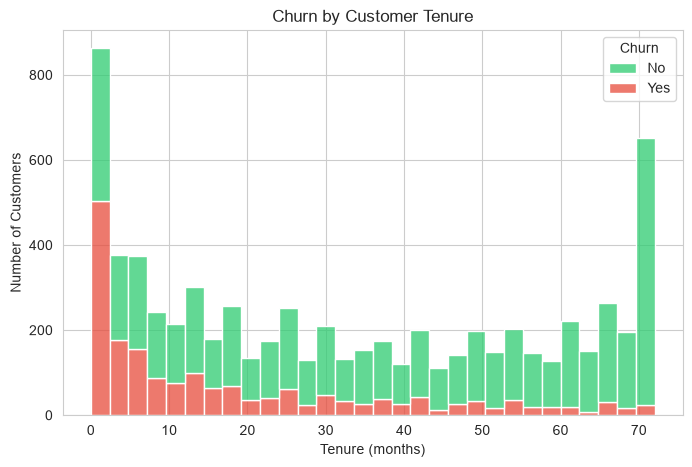

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='tenure', hue='Churn', multiple='stack', 
             palette=['#2ecc71', '#e74c3c'], bins=30)
plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

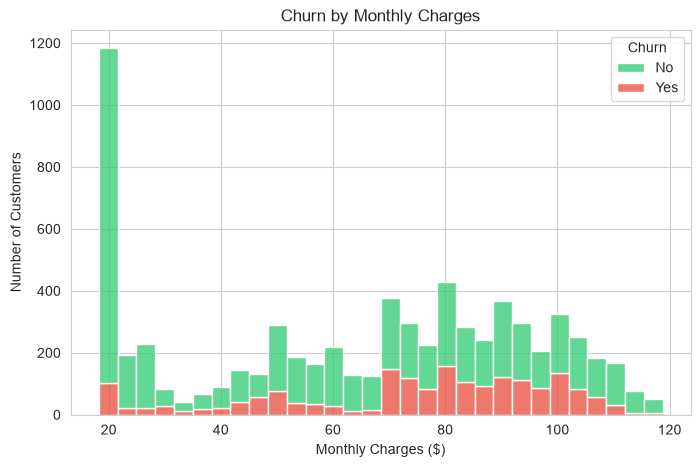

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='MonthlyCharges', hue='Churn', multiple='stack',
             palette=['#2ecc71', '#e74c3c'], bins=30)
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

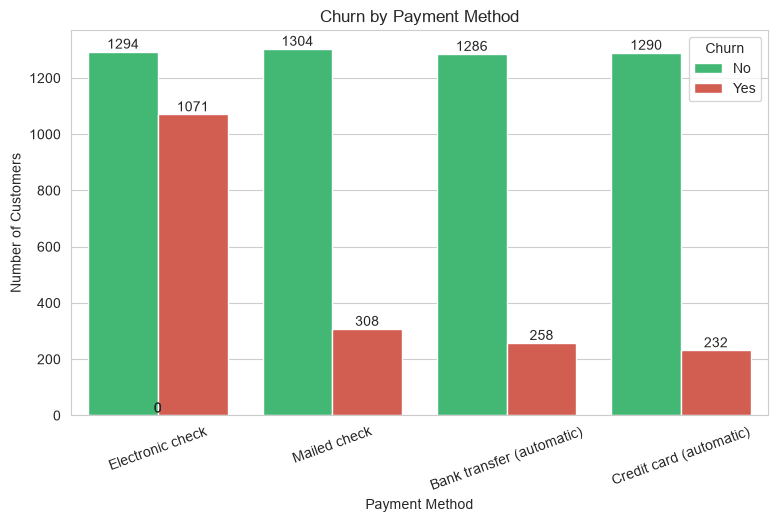

In [22]:
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df_clean, x='PaymentMethod', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.legend(title='Churn')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

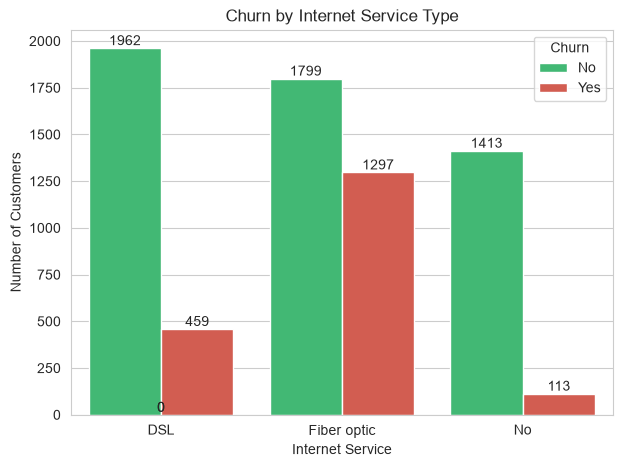

In [23]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df_clean, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

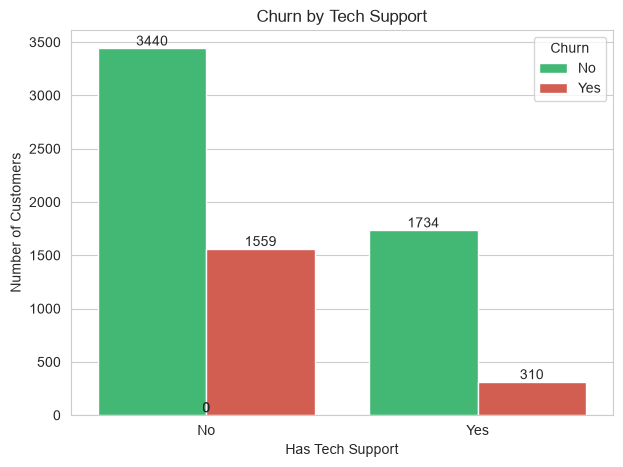

In [24]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df_clean, x='TechSupport', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Tech Support')
plt.xlabel('Has Tech Support')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

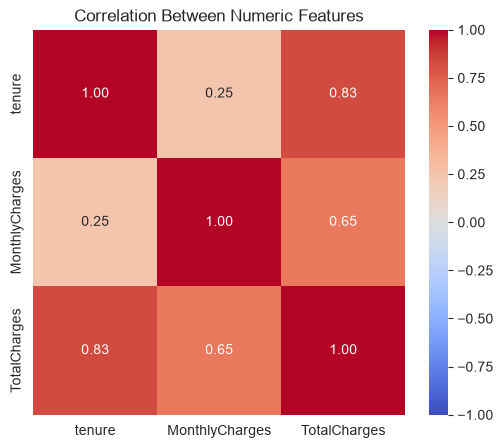

In [26]:
plt.figure(figsize=(6,5))
corr = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Between Numeric Features')
plt.show()

In [27]:
df_fe = df_clean.copy()

# 1. Tenure_Group
def tenure_group(t):
    if t <= 12:
        return 'New (0-12mo)'
    elif t <= 24:
        return 'Established (12-24mo)'
    elif t <= 48:
        return 'Loyal (24-48mo)'
    else:
        return 'Very Loyal (48mo+)'

df_fe['Tenure_Group'] = df_fe['tenure'].apply(tenure_group)

# 2. Service_Count
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['Service_Count'] = (df_fe[service_cols] == 'Yes').sum(axis=1)

# 3. Total_Services
df_fe['Total_Services'] = df_fe['Service_Count'] \
    + (df_fe['PhoneService'] == 'Yes').astype(int) \
    + (df_fe['InternetService'] != 'No').astype(int)

# 4. Avg_Monthly_Spend (safe division for tenure = 0)
df_fe['Avg_Monthly_Spend'] = df_fe.apply(
    lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else row['MonthlyCharges'],
    axis=1
)

# 5. Is_New_Customer
df_fe['Is_New_Customer'] = (df_fe['tenure'] <= 6).astype(int)

# Check the new features
df_fe[['tenure', 'Tenure_Group', 'Service_Count', 'Total_Services', 
       'Avg_Monthly_Spend', 'Is_New_Customer']].head(10)

,tenure,Tenure_Group,Service_Count,Total_Services,Avg_Monthly_Spend,Is_New_Customer
0,1,New (0-12mo),1,2,29.850000,1
1,34,Loyal (24-48mo),2,4,55.573529,0
2,2,New (0-12mo),2,4,54.075000,1
3,45,Loyal (24-48mo),3,4,40.905556,0
4,2,New (0-12mo),0,2,75.825000,1
5,8,New (0-12mo),3,5,102.562500,0
6,22,Established (12-24mo),2,4,88.609091,0
7,10,New (0-12mo),1,2,30.190000,0
8,28,Loyal (24-48mo),4,6,108.787500,0
9,62,Very Loyal (48mo+),2,4,56.257258,0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Drop non-predictive / redundant columns
df_model = df_fe.drop(columns=['customerID', 'TotalCharges'])

# 2. Separate target from features
X = df_model.drop(columns=['Churn'])
y = df_model['Churn'].map({'No': 0, 'Yes': 1})

# 3. Identify categorical vs numerical columns in X
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns to encode:", cat_cols)
print("\nNumerical columns:", num_cols)
print("\nX shape:", X.shape)
print("y distribution:\n", y.value_counts())

Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Tenure_Group']

Numerical columns: ['tenure', 'MonthlyCharges', 'Service_Count', 'Total_Services', 'Avg_Monthly_Spend', 'Is_New_Customer']

X shape: (7043, 23)
y distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [29]:
# 1. One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
print("\nSample columns after encoding:", X_encoded.columns.tolist()[:10])

Shape after encoding: (7043, 29)

Sample columns after encoding: ['tenure', 'MonthlyCharges', 'Service_Count', 'Total_Services', 'Avg_Monthly_Spend', 'Is_New_Customer', 'gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes']


In [30]:
# 2. Train/test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn ratio:\n", y_train.value_counts(normalize=True))
print("\nTest churn ratio:\n", y_test.value_counts(normalize=True))

Train shape: (5634, 29)
Test shape: (1409, 29)

Train churn ratio:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test churn ratio:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [31]:
# 3. Scale numerical features (for Logistic Regression only — tree models will use unscaled)
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling complete.")
print(X_train_scaled[num_cols].describe())

Scaling complete.
             tenure  MonthlyCharges  Service_Count  Total_Services  \
count  5.634000e+03    5.634000e+03    5634.000000    5.634000e+03   
mean  -1.008935e-17   -2.402527e-16       0.000000    4.035741e-17   
std    1.000089e+00    1.000089e+00       1.000089    1.000089e+00   
min   -1.322329e+00   -1.544028e+00      -1.109762   -1.302769e+00   
25%   -9.559779e-01   -9.711977e-01      -1.109762   -8.278855e-01   
50%   -1.418632e-01    1.848336e-01      -0.031297    1.218817e-01   
75%    9.164859e-01    8.319124e-01       0.507935    5.967654e-01   
max    1.608483e+00    1.785939e+00       2.125633    2.021416e+00   

       Avg_Monthly_Spend  Is_New_Customer  
count       5.634000e+03     5.634000e+03  
mean       -2.219658e-16    -2.143988e-17  
std         1.000089e+00     1.000089e+00  
min        -1.691127e+00    -5.119539e-01  
25%        -9.560071e-01    -5.119539e-01  
50%         1.869660e-01    -5.119539e-01  
75%         8.446212e-01    -5.119539e-01  

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, average_precision_score)

results = {}
predictions = {}
probabilities = {}

# 1. Logistic Regression (uses SCALED data)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
predictions['Logistic Regression'] = log_reg.predict(X_test_scaled)
probabilities['Logistic Regression'] = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Decision Tree (uses UNSCALED data)
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=6)
dt.fit(X_train, y_train)
predictions['Decision Tree'] = dt.predict(X_test)
probabilities['Decision Tree'] = dt.predict_proba(X_test)[:, 1]

# 3. Random Forest (uses UNSCALED data)
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
predictions['Random Forest'] = rf.predict(X_test)
probabilities['Random Forest'] = rf.predict_proba(X_test)[:, 1]

# 4. Gradient Boosting (uses UNSCALED data)
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
predictions['Gradient Boosting'] = gb.predict(X_test)
probabilities['Gradient Boosting'] = gb.predict_proba(X_test)[:, 1]

# 5. XGBoost (uses UNSCALED data)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, 
                     eval_metric='logloss')
xgb.fit(X_train, y_train)
predictions['XGBoost'] = xgb.predict(X_test)
probabilities['XGBoost'] = xgb.predict_proba(X_test)[:, 1]

print("All 5 models trained successfully.")

All 5 models trained successfully.


In [33]:
# Build comparison table using REAL predictions from the models we just trained
comparison = []

for name in predictions:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.7410,0.5076,0.8021,0.6218,0.8451,0.6513
3,Gradient Boosting,0.7999,0.6597,0.5080,0.5740,0.8431,0.6564
1,Decision Tree,0.7346,0.5000,0.8209,0.6215,0.8280,0.6040
2,Random Forest,0.7637,0.5476,0.6310,0.5863,0.8246,0.6112
4,XGBoost,0.7601,0.5385,0.6738,0.5986,0.8242,0.6192


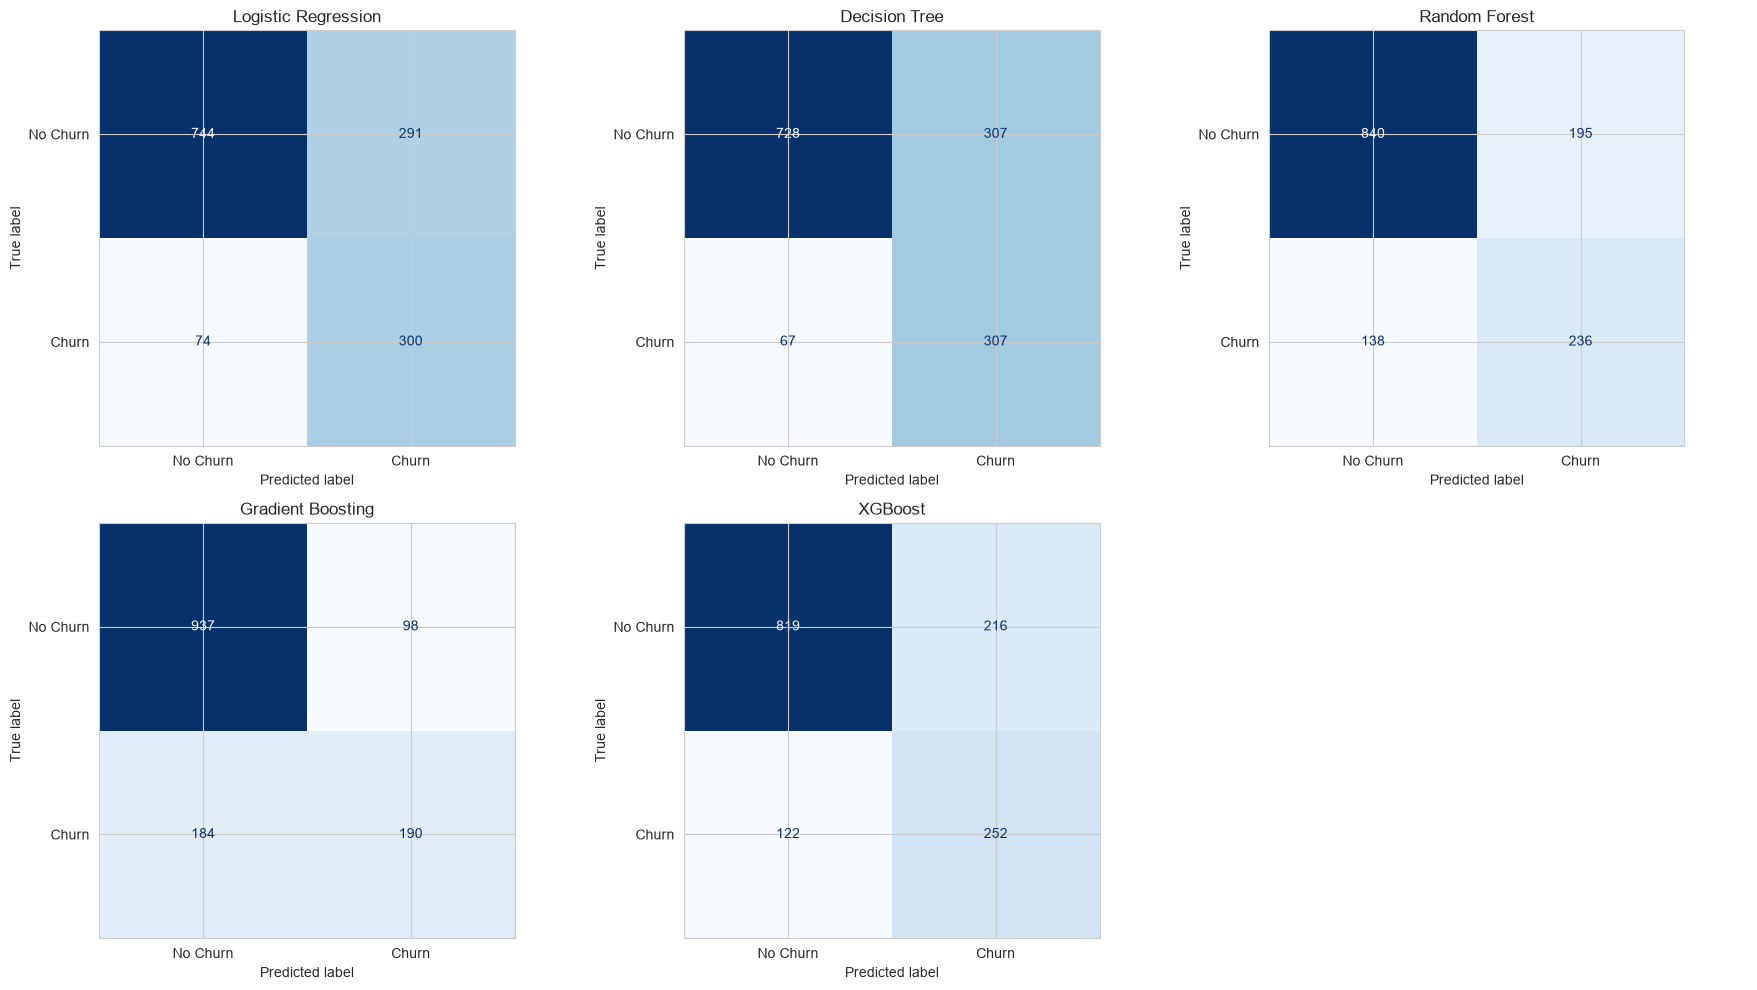

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, name in enumerate(predictions):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name)

axes[5].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.show()

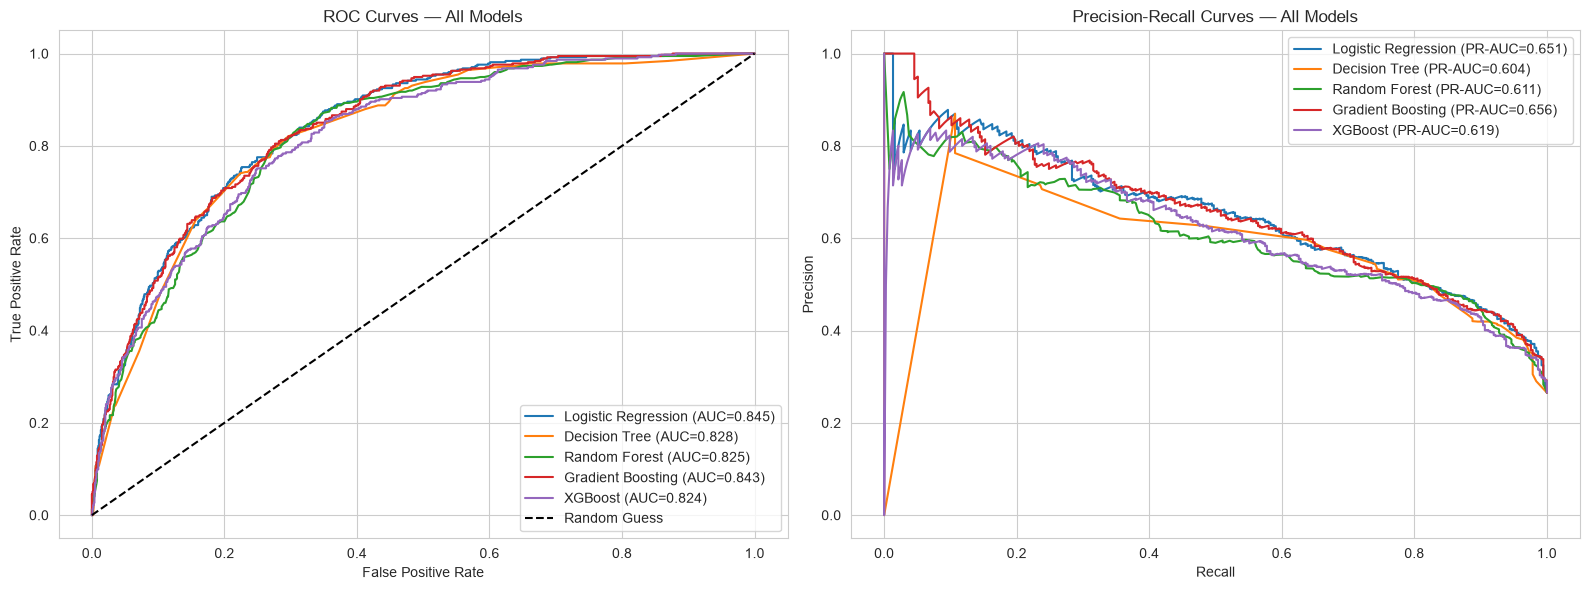

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for name in probabilities:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend()

# Precision-Recall Curve
for name in probabilities:
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    pr_auc = average_precision_score(y_test, probabilities[name])
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC={pr_auc:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Feature importance from Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top 15 most influential features (by absolute coefficient):")
coef_df.head(15)

Top 15 most influential features (by absolute coefficient):


,Feature,Coefficient
21,Contract_Two year,-1.596417
12,InternetService_Fiber optic,1.149362
13,InternetService_No,-0.924358
20,Contract_One year,-0.725397
0,tenure,-0.547164
14,OnlineSecurity_Yes,-0.455338
10,PhoneService_Yes,-0.412935
17,TechSupport_Yes,-0.390238
24,PaymentMethod_Electronic check,0.380114
11,MultipleLines_Yes,0.363204


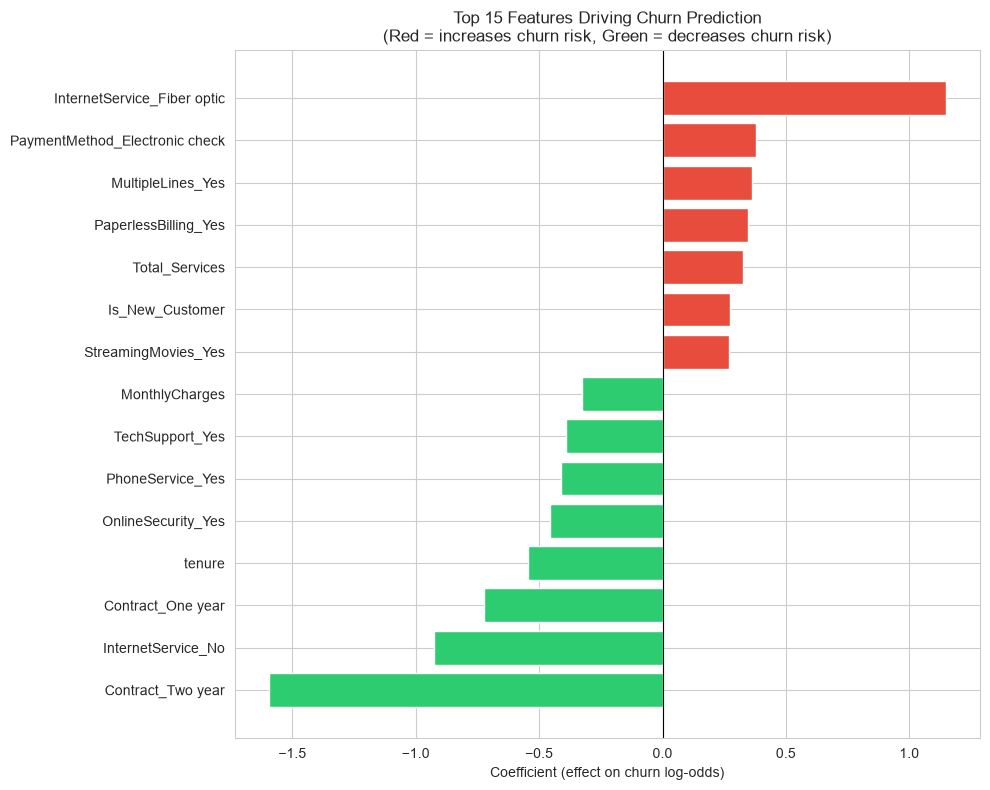

In [37]:
# Visualize
plt.figure(figsize=(10, 8))
top_15 = coef_df.head(15).sort_values('Coefficient')
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_15['Coefficient']]
plt.barh(top_15['Feature'], top_15['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Driving Churn Prediction\n(Red = increases churn risk, Green = decreases churn risk)')
plt.xlabel('Coefficient (effect on churn log-odds)')
plt.tight_layout()
plt.show()

In [38]:
import shap

# SHAP for Logistic Regression uses a linear explainer (fast, exact for linear models)
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values computed. Shape:", shap_values.shape)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values computed. Shape: (1409, 29)


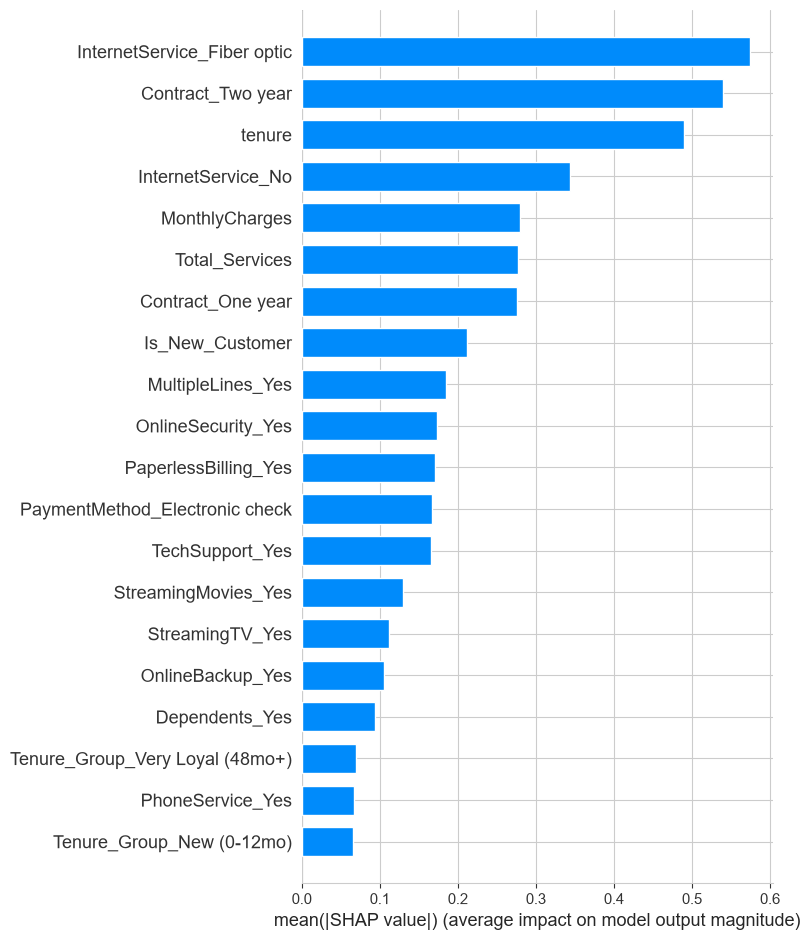

In [39]:
# Global SHAP summary — confirms feature importance from a different angle
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

In [40]:
# Get churn probabilities for all test customers using our selected model (Logistic Regression)
churn_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Build a results dataframe, keeping original customerID for reference
test_indices = X_test.index
customer_ids = df_fe.loc[test_indices, 'customerID'].values

results_df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Churn_Probability': churn_probs,
    'Actual_Churn': y_test.values
})

results_df = results_df.sort_values('Churn_Probability', ascending=False)
print("Top 10 highest-risk customers (real predictions):")
results_df.head(10)

Top 10 highest-risk customers (real predictions):


,CustomerID,Churn_Probability,Actual_Churn
1090,5178-LMXOP,0.963761,1
1138,1400-MMYXY,0.956944,1
1221,0295-PPHDO,0.955993,1
647,6023-YEBUP,0.954740,1
627,9057-SIHCH,0.952226,1
889,2545-EBUPK,0.948555,0
1109,1069-XAIEM,0.948552,1
1355,6630-UJZMY,0.946389,0
510,4750-ZRXIU,0.945812,1
1197,2865-TCHJW,0.944457,1


In [41]:
# ============================================
# CONFIGURABLE RISK THRESHOLDS
# Adjust these based on business needs — not universal values
# ============================================
RISK_THRESHOLDS = {
    'LOW': 0.30,      # below this = LOW risk
    'MEDIUM': 0.60    # between LOW and this = MEDIUM, above = HIGH
}

def assign_risk_level(prob, thresholds=RISK_THRESHOLDS):
    if prob < thresholds['LOW']:
        return 'LOW'
    elif prob < thresholds['MEDIUM']:
        return 'MEDIUM'
    else:
        return 'HIGH'

results_df['Risk_Level'] = results_df['Churn_Probability'].apply(assign_risk_level)

print("Risk level distribution:")
print(results_df['Risk_Level'].value_counts())

Risk level distribution:
Risk_Level
LOW       610
HIGH      469
MEDIUM    330
Name: count, dtype: int64


In [42]:
# Build a SHAP values dataframe aligned with X_test
shap_df = pd.DataFrame(shap_values, columns=X_test_scaled.columns, index=X_test.index)

def get_top_risk_factors(customer_row_index, n=3):
    """
    Returns the top N features pushing THIS customer's prediction toward churn.
    Only positive SHAP values are considered (features increasing churn risk).
    """
    customer_shap = shap_df.loc[customer_row_index]
    # Only features that push toward churn (positive SHAP value)
    risk_factors = customer_shap[customer_shap > 0].sort_values(ascending=False)
    return ', '.join(risk_factors.head(n).index.tolist())

# Apply to every customer in the test set
results_df['Top_Risk_Factors'] = [
    get_top_risk_factors(idx, n=3) for idx in X_test.index
]

# Reorder columns nicely
results_df = results_df[['CustomerID', 'Churn_Probability', 'Risk_Level', 'Top_Risk_Factors', 'Actual_Churn']]

print("Sample: Top 10 highest-risk customers with explanations")
results_df.sort_values('Churn_Probability', ascending=False).head(10)

Sample: Top 10 highest-risk customers with explanations


,CustomerID,Churn_Probability,Risk_Level,Top_Risk_Factors,Actual_Churn
1090,5178-LMXOP,0.963761,HIGH,"Total_Services, InternetService_Fiber optic, I...",1
1138,1400-MMYXY,0.956944,HIGH,"InternetService_Fiber optic, tenure, Contract_...",1
1221,0295-PPHDO,0.955993,HIGH,"Total_Services, Contract_Two year, InternetSer...",1
647,6023-YEBUP,0.954740,HIGH,"InternetService_Fiber optic, tenure, Contract_...",1
627,9057-SIHCH,0.952226,HIGH,"Total_Services, InternetService_No, Contract_O...",1
889,2545-EBUPK,0.948555,HIGH,"InternetService_Fiber optic, Contract_Two year...",0
1109,1069-XAIEM,0.948552,HIGH,"InternetService_Fiber optic, Total_Services, C...",1
1355,6630-UJZMY,0.946389,HIGH,"MonthlyCharges, tenure, Contract_Two year",0
510,4750-ZRXIU,0.945812,HIGH,"MonthlyCharges, Contract_One year, TechSupport...",1
1197,2865-TCHJW,0.944457,HIGH,"tenure, Contract_Two year, PaymentMethod_Elect...",1


In [43]:
pd.set_option('display.max_colwidth', None)
results_df.sort_values('Churn_Probability', ascending=False).head(10)[
    ['CustomerID', 'Churn_Probability', 'Risk_Level', 'Top_Risk_Factors']
]

,CustomerID,Churn_Probability,Risk_Level,Top_Risk_Factors
1090,5178-LMXOP,0.963761,HIGH,"Total_Services, InternetService_Fiber optic, InternetService_No"
1138,1400-MMYXY,0.956944,HIGH,"InternetService_Fiber optic, tenure, Contract_Two year"
1221,0295-PPHDO,0.955993,HIGH,"Total_Services, Contract_Two year, InternetService_No"
647,6023-YEBUP,0.954740,HIGH,"InternetService_Fiber optic, tenure, Contract_Two year"
627,9057-SIHCH,0.952226,HIGH,"Total_Services, InternetService_No, Contract_One year"
889,2545-EBUPK,0.948555,HIGH,"InternetService_Fiber optic, Contract_Two year, tenure"
1109,1069-XAIEM,0.948552,HIGH,"InternetService_Fiber optic, Total_Services, Contract_Two year"
1355,6630-UJZMY,0.946389,HIGH,"MonthlyCharges, tenure, Contract_Two year"
510,4750-ZRXIU,0.945812,HIGH,"MonthlyCharges, Contract_One year, TechSupport_Yes"
1197,2865-TCHJW,0.944457,HIGH,"tenure, Contract_Two year, PaymentMethod_Electronic check"


In [44]:
def generate_recommendation(row):
    """
    Maps risk level + top risk factors to a business action.
    Rules are based on patterns confirmed in EDA/modeling for THIS dataset only.
    """
    if row['Risk_Level'] == 'LOW':
        return "No action needed — monitor periodically."
    
    factors = row['Top_Risk_Factors']
    actions = []
    
    # Contract-related risk
    if 'Contract_Two year' in factors or 'Contract_One year' in factors or 'tenure' in factors:
        actions.append("Offer a discounted longer-term contract upgrade")
    
    # Internet service / pricing risk
    if 'InternetService_Fiber optic' in factors or 'MonthlyCharges' in factors:
        actions.append("Review pricing/package value for this customer's service tier")
    
    # Payment method risk
    if 'PaymentMethod_Electronic check' in factors:
        actions.append("Encourage switch to automatic payment (bank transfer/credit card)")
    
    # Support-related risk
    if 'TechSupport_Yes' in factors or 'OnlineSecurity_Yes' in factors:
        actions.append("Proactive customer support / service check-in")
    
    # New customer risk
    if 'Is_New_Customer' in factors or 'Tenure_Group_New (0-12mo)' in factors:
        actions.append("Early-stage retention campaign / onboarding follow-up")
    
    if not actions:
        actions.append("General retention outreach recommended")
    
    urgency = "URGENT: " if row['Risk_Level'] == 'HIGH' else ""
    return urgency + "; ".join(actions)

results_df['Recommended_Action'] = results_df.apply(generate_recommendation, axis=1)

pd.set_option('display.max_colwidth', None)
print("Final customer risk & recommendation table (Top 10 highest risk):")
results_df.sort_values('Churn_Probability', ascending=False).head(10)[
    ['CustomerID', 'Churn_Probability', 'Risk_Level', 'Top_Risk_Factors', 'Recommended_Action']
]

Final customer risk & recommendation table (Top 10 highest risk):


,CustomerID,Churn_Probability,Risk_Level,Top_Risk_Factors,Recommended_Action
1090,5178-LMXOP,0.963761,HIGH,"Total_Services, InternetService_Fiber optic, InternetService_No",URGENT: Review pricing/package value for this customer's service tier
1138,1400-MMYXY,0.956944,HIGH,"InternetService_Fiber optic, tenure, Contract_Two year",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier
1221,0295-PPHDO,0.955993,HIGH,"Total_Services, Contract_Two year, InternetService_No",URGENT: Offer a discounted longer-term contract upgrade
647,6023-YEBUP,0.954740,HIGH,"InternetService_Fiber optic, tenure, Contract_Two year",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier
627,9057-SIHCH,0.952226,HIGH,"Total_Services, InternetService_No, Contract_One year",URGENT: Offer a discounted longer-term contract upgrade
889,2545-EBUPK,0.948555,HIGH,"InternetService_Fiber optic, Contract_Two year, tenure",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier
1109,1069-XAIEM,0.948552,HIGH,"InternetService_Fiber optic, Total_Services, Contract_Two year",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier
1355,6630-UJZMY,0.946389,HIGH,"MonthlyCharges, tenure, Contract_Two year",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier
510,4750-ZRXIU,0.945812,HIGH,"MonthlyCharges, Contract_One year, TechSupport_Yes",URGENT: Offer a discounted longer-term contract upgrade; Review pricing/package value for this customer's service tier; Proactive customer support / service check-in
1197,2865-TCHJW,0.944457,HIGH,"tenure, Contract_Two year, PaymentMethod_Electronic check",URGENT: Offer a discounted longer-term contract upgrade; Encourage switch to automatic payment (bank transfer/credit card)


In [45]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save everything the dashboard needs to make predictions
artifacts = {
    'model': log_reg,
    'scaler': scaler,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'feature_columns': X_train_scaled.columns.tolist(),  # exact column order after encoding
    'risk_thresholds': RISK_THRESHOLDS
}

with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [46]:
# Also save the cleaned + engineered dataset (used for dashboard analytics pages)
df_fe.to_csv('../data/processed/telco_churn_processed.csv', index=False)

# Save full test-set predictions (used for Model Performance page)
eval_results = pd.DataFrame({
    'CustomerID': customer_ids,
    'Actual_Churn': y_test.values,
})
for name in predictions:
    eval_results[f'{name}_Pred'] = predictions[name]
    eval_results[f'{name}_Prob'] = probabilities[name]

eval_results.to_csv('../data/processed/model_predictions.csv', index=False)
comparison_df.to_csv('../data/processed/model_comparison.csv', index=False)

print("Processed data and evaluation results saved.")

Processed data and evaluation results saved.
